In [1]:
import pandas as pd
import matplotlib as plt

In [10]:
user_df = pd.read_csv('../data/user_session_interactions.csv')
mood_df = pd.read_csv('../data/mood_journal_entries.csv')


In [11]:
user_df.head()

,user_id,session_id,timestamp,completed,liked,tags
0,user_2,session_1,2025-06-29T23:40:23.637314,True,False,"['sleep', 'breathing']"
1,user_8,session_4,2025-06-05T23:40:23.637367,False,True,"['breathing', 'focus', 'anxiety']"
2,user_2,session_2,2025-06-22T23:40:23.637382,True,False,"['stress', 'anxiety', 'focus']"
3,user_1,session_9,2025-06-14T23:40:23.637398,True,True,"['stress', 'sleep']"
4,user_5,session_6,2025-06-25T23:40:23.637434,True,False,"['breathing', 'stress', 'sleep']"


In [13]:
mood_df.head()

,user_id,timestamp,entry,manually_labeled_emotion
0,user_3,2025-06-28T23:40:23.644767,Just tired and drained.,tired
1,user_9,2025-06-19T23:40:23.644793,Feeling overwhelmed with work today.,content
2,user_7,2025-06-23T23:40:23.644803,Feeling anxious about upcoming exams.,tired
3,user_4,2025-06-29T23:40:23.644812,Struggling to sleep lately.,happy
4,user_6,2025-06-11T23:40:23.644822,Feeling overwhelmed with work today.,tired


### User Session Interaction EDA

#### Distribution of tags

In [40]:

tags_col = list(user_df['tags'])

tags = [j.strip("'[]\" ") for i in tags_col for j in i.split(',')]

tags_series = pd.Series(tags)


In [41]:
tags_series.value_counts()

breathing    39
stress       37
sleep        34
anxiety      33
focus        31
gratitude    20
Name: count, dtype: int64

(array([34.,  0., 39.,  0., 31.,  0., 33.,  0., 37., 20.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

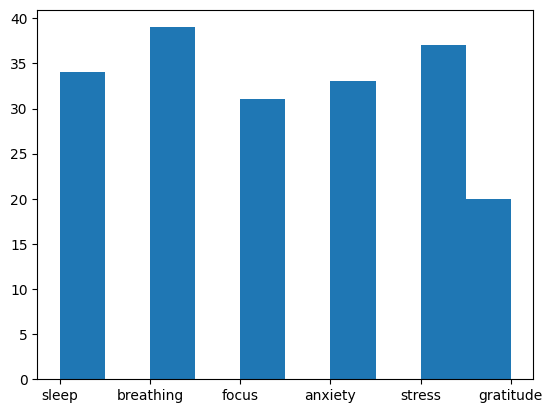

In [42]:
plt.pyplot.hist(tags)

#### Distribution of mood entries

In [43]:
mood_df['manually_labeled_emotion'].value_counts()

manually_labeled_emotion
tired      15
content     9
angry       9
sad         7
happy       6
anxious     4
Name: count, dtype: int64

In [71]:
mood_df['day'] = pd.to_datetime(mood_df['timestamp']).dt.day_name()

mood_df.head()

,user_id,timestamp,entry,manually_labeled_emotion,day
0,user_3,2025-06-28T23:40:23.644767,Just tired and drained.,tired,Saturday
1,user_9,2025-06-19T23:40:23.644793,Feeling overwhelmed with work today.,content,Thursday
2,user_7,2025-06-23T23:40:23.644803,Feeling anxious about upcoming exams.,tired,Monday
3,user_4,2025-06-29T23:40:23.644812,Struggling to sleep lately.,happy,Sunday
4,user_6,2025-06-11T23:40:23.644822,Feeling overwhelmed with work today.,tired,Wednesday


In [80]:
day_emotion_int = mood_df['manually_labeled_emotion'].groupby(mood_df['day']).value_counts()
day_emotion_int

day        manually_labeled_emotion
Friday     angry                       2
           tired                       2
Monday     angry                       2
           content                     2
           anxious                     1
           tired                       1
Saturday   sad                         2
           tired                       2
           anxious                     1
           content                     1
           happy                       1
Sunday     sad                         3
           anxious                     2
           content                     2
           tired                       2
           angry                       1
           happy                       1
Thursday   tired                       3
           angry                       2
           content                     2
           happy                       2
Tuesday    tired                       3
           sad                         2
           angry     